In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from datetime import datetime
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from scipy.spatial import ConvexHull
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

from scipy.interpolate import UnivariateSpline



## 1.Fundemental Diagram Calibration

In [63]:
import xml.etree.ElementTree as ET

def parse_edge_to_dataframe(xml_file):
    """
    Parses the XML file and extracts edge data into a DataFrame.
    
    Parameters:
    xml_file (str): Path to the XML file.
    
    Returns:
    pd.DataFrame: DataFrame containing edge id, speed, and density.
    """
    tree = ET.parse(xml_file)
    root = tree.getroot()

    data = []
    for edge in root.iter('edge'):
        edge_id = edge.get('id')
        speed = float(edge.get('speed'))
        density = float(edge.get('density'))
        flow = speed*density*3.6
        data.append({'edge_id': edge_id, 'speed': speed, 'flow': flow, 'density': density})

    return pd.DataFrame(data)


def parse_detector_to_dataframe(xml_file):
    """
    Parses the XML file and extracts edge data into a DataFrame.
    
    Parameters:
    xml_file (str): Path to the XML file.
    
    Returns:
    pd.DataFrame: DataFrame containing edge id, speed, and density.
    """
    tree = ET.parse(xml_file)
    root = tree.getroot()

    data = []
    for detector in root.iter('interval'):
        # detec_id = detector.get('id')
        # time_speed = float(detector.get('speed'))
        space_speed = float(detector.get('harmonicMeanSpeed'))
        flow = float(detector.get('flow'))
        # occ = float(detector.get('occupancy'))
        # l = float(detector.get('length'))
        if not (space_speed == -1 or flow ==0):
            detec_id = detector.get('id')
            time_speed = float(detector.get('speed'))
            space_speed = float(detector.get('harmonicMeanSpeed'))
            flow = float(detector.get('flow'))
            occ = float(detector.get('occupancy'))
            l = float(detector.get('length'))
            density = 10*occ/(2.5+l)
            flow = density * space_speed * 3.6 if density * space_speed * 3.6<1970 else 0
            # density = flow/(3.6*space_speed)
            data.append({'id': detec_id, 'Speed': space_speed, 'Flow': flow, 'Density': density, 'Occupancy': occ})

    return pd.DataFrame(data)

In [64]:
from scipy.optimize import curve_fit

def piecewise_linear(x, x_break, k1, k2):
    return np.piecewise(x, [x < x_break, x >= x_break],
                        [lambda x: k1 * x,
                         lambda x: k2 * (x - x_break) + k1 * x_break])

def constrained_piecewise_fit(x, y):
    # Constrain the second slope (k2) to be negative
    p0 = [np.median(x), 1, -1]  # initial guess

    # Fit the model
    bounds = ([min(x), 0, -np.inf], [max(x), np.inf, 0])  # constrain k2 < 0
    params, _ = curve_fit(piecewise_linear, x, y, p0=p0, bounds=bounds)

    x_0 = 34.32
    k_1 = 57.6
    return x_0, k_1, (x_0*k_1)/(x_0-133)
 
    # return params

def plot_and_fit_piecewise(df, x_col, y_col):
    # Extract the data for the specified columns
    x = df[x_col].values
    y = df[y_col].values

    # Fit the piecewise function to the data with constrained second slope
    params = constrained_piecewise_fit(x, y)
    # Extract parameters
    x_break, k1, k2 = params
    # x_break, k1, k2 = 85.89, 43.95, -20.5

    # Create the scatter plot
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, label='Data')

    # Plot the piecewise linear fit
    x_range = np.linspace(min(x), max(x)+20, 500)
#     y_range = np.linspace(0, 2300)
    plt.plot(x_range, piecewise_linear(x_range, *params), color='red', label='Piecewise Linear Fit')

    # Display the equations for the piecewise function in the top right corner
    plt.text(0.95, 0.95, f'y = {k1:.2f} * x  (x < {x_break:.2f})', transform=plt.gca().transAxes,
             verticalalignment='top', horizontalalignment='right')
    plt.text(0.95, 0.90, f'y = {k1 * x_break:.2f} + {k2:.2f} * (x - {x_break:.2f})  (x >= {x_break:.2f})',
             transform=plt.gca().transAxes, verticalalignment='top', horizontalalignment='right')

    # Customize plot
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f'Scatter Plot and Piecewise Linear Fit\n({x_col} vs {y_col})')
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.ylim(0,3500)
    plt.show()

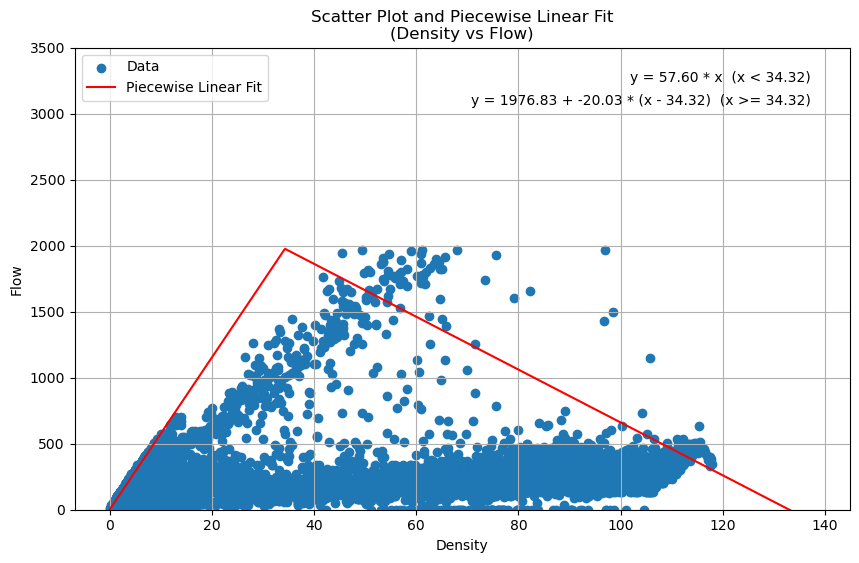

In [65]:
detector_df = parse_detector_to_dataframe('detector_out.xml')
plot_and_fit_piecewise(detector_df, 'Density', 'Flow')

In [14]:
def plot_detector(dataframe, para_x = 'Density', para_y = 'Speed'):
    """
    Plots a scatter plot of speed versus density for each edge.
    
    Parameters:
    dataframe (pd.DataFrame): DataFrame containing edge id, speed, and density.
    
    Returns:
    None: Displays the plot.
    """
    plt.figure(figsize=(14, 8))
    scatter = plt.scatter(dataframe[para_x], dataframe[para_y], s=50, alpha=0.7)
    plt.title('Scatter Plot of {} vs {}'.format(para_x, para_y))
    plt.xlabel(para_x)
    plt.ylabel(para_y)
    # plt.xlim(0, 300)
    plt.ylim(0, 25)
    plt.show()

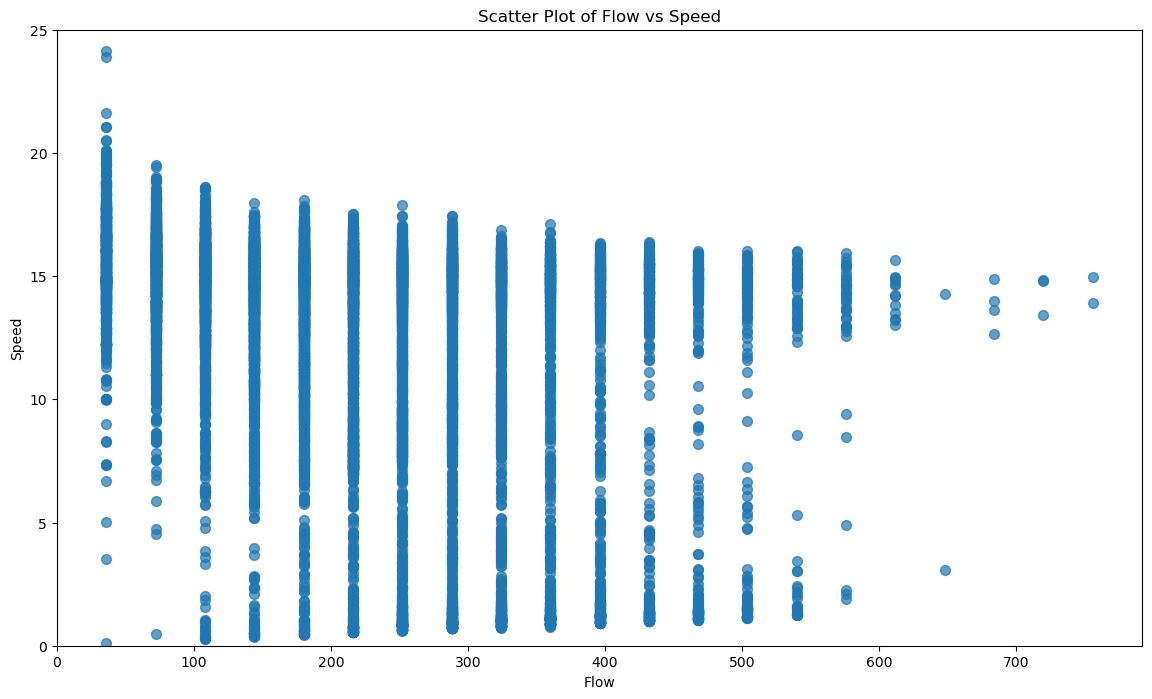

In [15]:
detector_df = parse_detector_to_dataframe('detector_out.xml')
plot_detector(detector_df, 'Flow', 'Speed')

#### Flow Density FD

## CTM Preprocess

In [66]:
# Step 1: Load the CSV File and Convert to DataFrame
time_id_matrix_path = 'CTMnumber_3600_1800dis.csv'
time_id_matrix = pd.read_csv(time_id_matrix_path)

# Display the first few rows to understand the structure
# print(time_id_matrix.head())

# Step 2: Combine Cell Numbers by Link
# Extract the link ID from the cell ID
time_id_matrix['link_id'] = time_id_matrix.iloc[:, 0].apply(lambda x: x.split('.')[1])

# Group by link ID and sum the number of vehicles for each time step
link_grouped = time_id_matrix.groupby('link_id').sum()

# Drop the cell ID column (first column)
link_grouped = link_grouped.drop(columns=time_id_matrix.columns[0])

# Display the first few rows of the grouped DataFrame
# print(link_grouped.head())

In [67]:
link_grouped.to_csv('CTMcombinedVehNum.csv')

## 2.CTM Performance Evaluation

In [68]:
def plot_vehicles_over_time(dataframe, time_resolution=1, selected_edges=None):
    """
    Plots the number of vehicles over time for each link.

    Parameters:
    dataframe (pd.DataFrame): DataFrame with columns ['link_id', 'time_1', 'time_2', ..., 'time_n'].
    time_resolution (int): Interval for time steps to plot.

    Returns:
    None: Displays a plot.
    """

    if selected_edges is not None:
        dataframe = dataframe[dataframe['link_id'].isin(selected_edges)]
    
    # Melt the dataframe to have columns ['link_id', 'time_step', 'vehicle_number']
    melted_df = dataframe.melt(id_vars=['link_id'], var_name='time_step', value_name='vehicle_number')
    
    # Extract the numerical part of the time step
    melted_df['time_step'] = melted_df['time_step'].str.extract('(\d+)').astype(int)
    
    # Filter based on the time resolution
    melted_df = melted_df[melted_df['time_step'] % time_resolution == 0]
    
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Set the color palette
    palette = sns.color_palette("hsv", len(melted_df['link_id'].unique()))
    color_mapping = dict(zip(melted_df['link_id'].unique(), palette))
    
    # Plot each link with a different color
    for link_id in melted_df['link_id'].unique():
        link_data = melted_df[melted_df['link_id'] == link_id]
        ax.plot(link_data['time_step'], link_data['vehicle_number'], label=link_id, color=color_mapping[link_id])
        
    ax.set_title('Number of Vehicles Over Time for Each Link')
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Number of Vehicles')
    ax.legend(title='Link ID', bbox_to_anchor=(1.25, 1), loc='upper left')
    
    plt.show()

### Visulization

In [69]:
# Example usage:
# Load the example data
ctm_number_path = 'CTMcombinedVehNum.csv'
sim_number_path = 'Linknumber_sim.csv'

ctm_veh_num_df = pd.read_csv(ctm_number_path)
sim_veh_num_df = pd.read_csv(sim_number_path)

sim_veh_num_df.columns = ['link_id'] + list(sim_veh_num_df.columns[1:])

# Define the link IDs to visualize
link_select = ['E28', '-E28', 'E17', '-E17', 'E18', '-E18', 'E115']


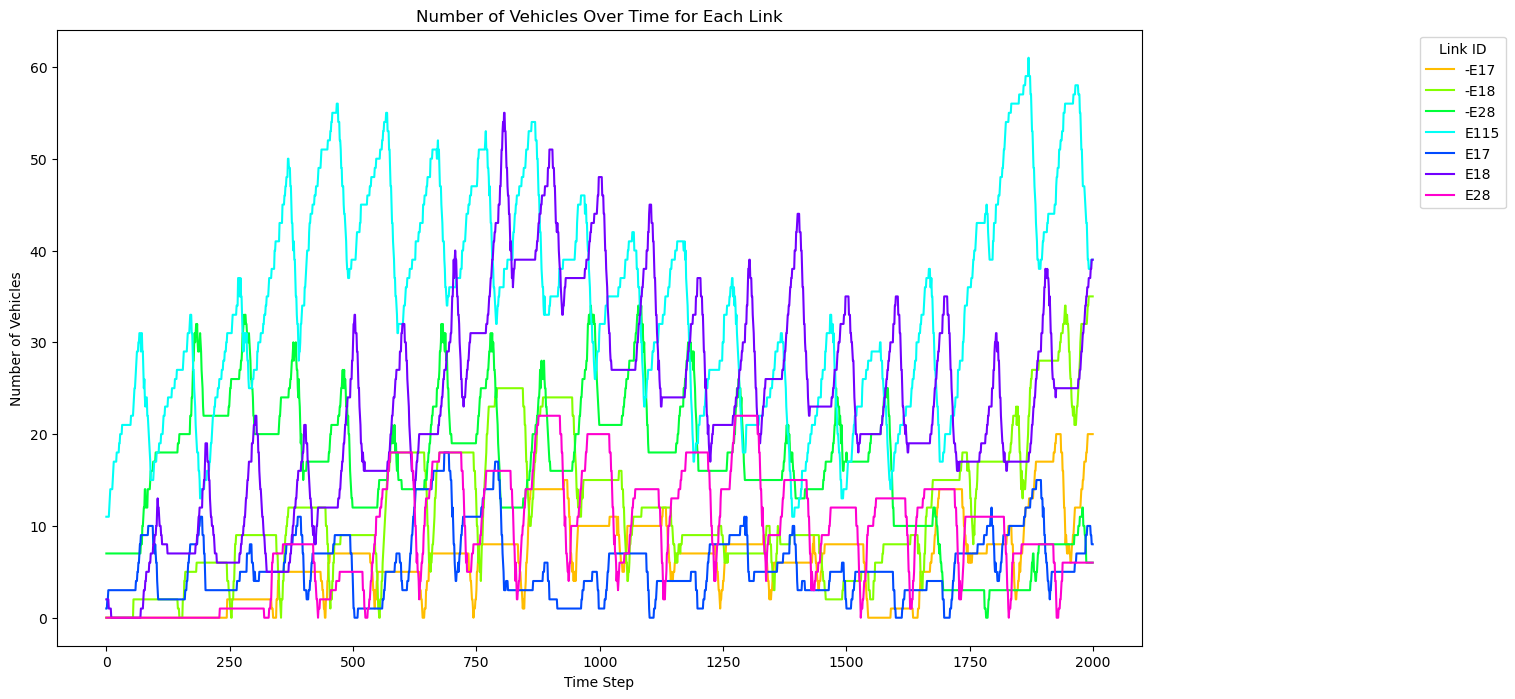

In [72]:
plot_vehicles_over_time(sim_veh_num_df, 1, link_select)

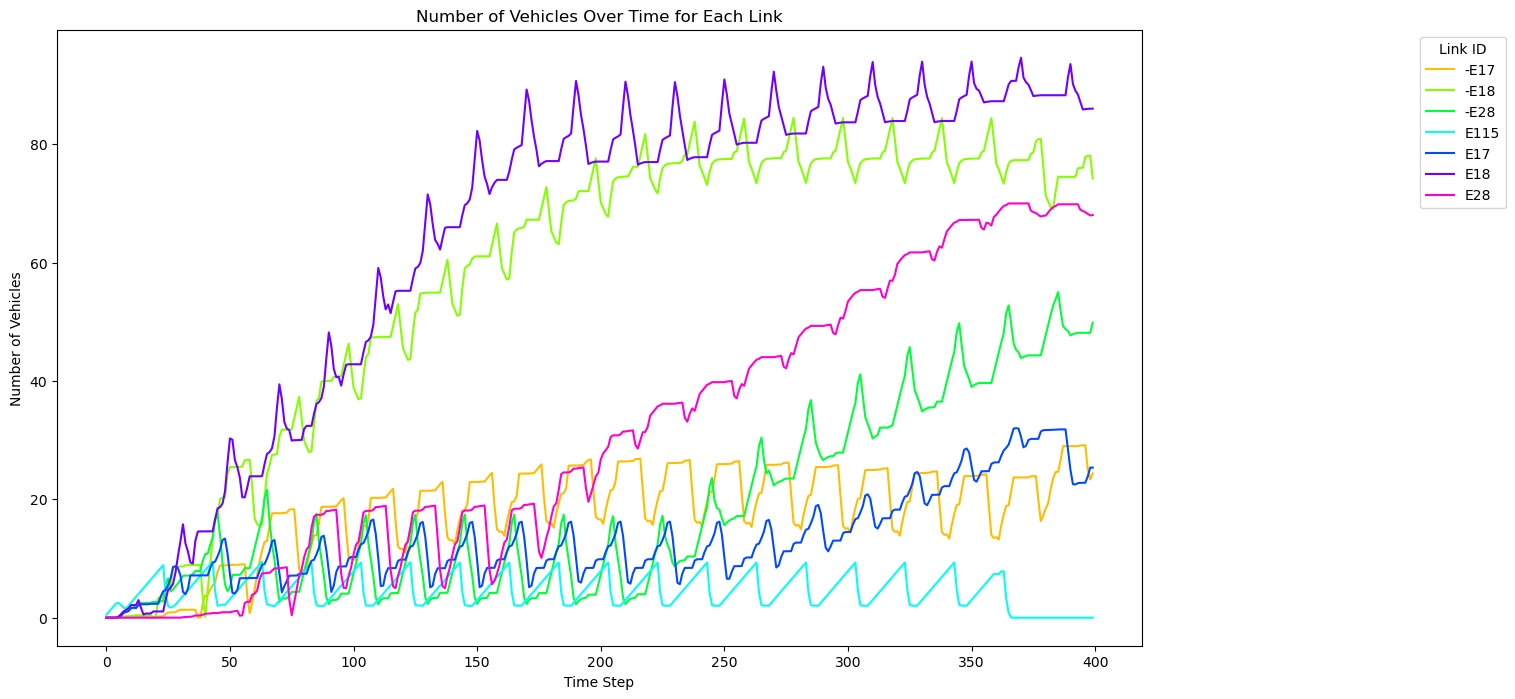

In [79]:
plot_vehicles_over_time(ctm_veh_num_df.iloc[:, :401] , 1, link_select)

In [78]:
# ctm_veh_num_df

In [ ]:
# Step 3: Create Time-Space Visualization
# Transpose the DataFrame to have time steps as columns
link_grouped_transposed = link_grouped.T

# Plot the heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(link_grouped_transposed, cmap='viridis', cbar_kws={'label': 'Number of Vehicles'})
plt.title('Time-Space Visualization of Number of Vehicles for Each Link')
plt.xlabel('Link ID')
plt.ylabel('Time Step')
plt.show()

### CTM cell level evaluation

In [542]:
def plot_cell_vehicle_number(dataframe, time_resolution=1, selected_cells=None):
    """
    Plots the number of vehicles over time for each link.

    Parameters:
    dataframe (pd.DataFrame): DataFrame with columns 
    time_resolution (int): Interval for time steps to plot.

    Returns:
    None: Displays a plot.
    """
    
    if selected_cells is not None:
        dataframe = dataframe[dataframe['cell_id'].isin(selected_cells)]
    
    # Melt the dataframe to have columns ['link_id', 'time_step', 'vehicle_number']
    melted_df = dataframe.melt(id_vars=['cell_id'], var_name='time_step', value_name='vehicle_number')
    
    # Extract the numerical part of the time step
    melted_df['time_step'] = melted_df['time_step'].str.extract('(\d+)').astype(int)
    
    # Filter based on the time resolution
    melted_df = melted_df[melted_df['time_step'] % time_resolution == 0]
    
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Set the color palette
    palette = sns.color_palette("hsv", len(melted_df['cell_id'].unique()))
    color_mapping = dict(zip(melted_df['cell_id'].unique(), palette))
    
    # Plot each link with a different color
    for link_id in melted_df['cell_id'].unique():
        link_data = melted_df[melted_df['cell_id'] == link_id]
        ax.plot(link_data['time_step'], link_data['vehicle_number'], label=link_id, color=color_mapping[link_id])
        
    ax.set_title('Number of Vehicles Over Time for Each Link')
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Number of Vehicles')
    ax.legend(title='Cell ID', bbox_to_anchor=(1.25, 1), loc='upper left')
    
    plt.show()

<>:20: SyntaxWarning: invalid escape sequence '\d'
<>:20: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1128316/838715738.py:20: SyntaxWarning: invalid escape sequence '\d'
  melted_df['time_step'] = melted_df['time_step'].str.extract('(\d+)').astype(int)


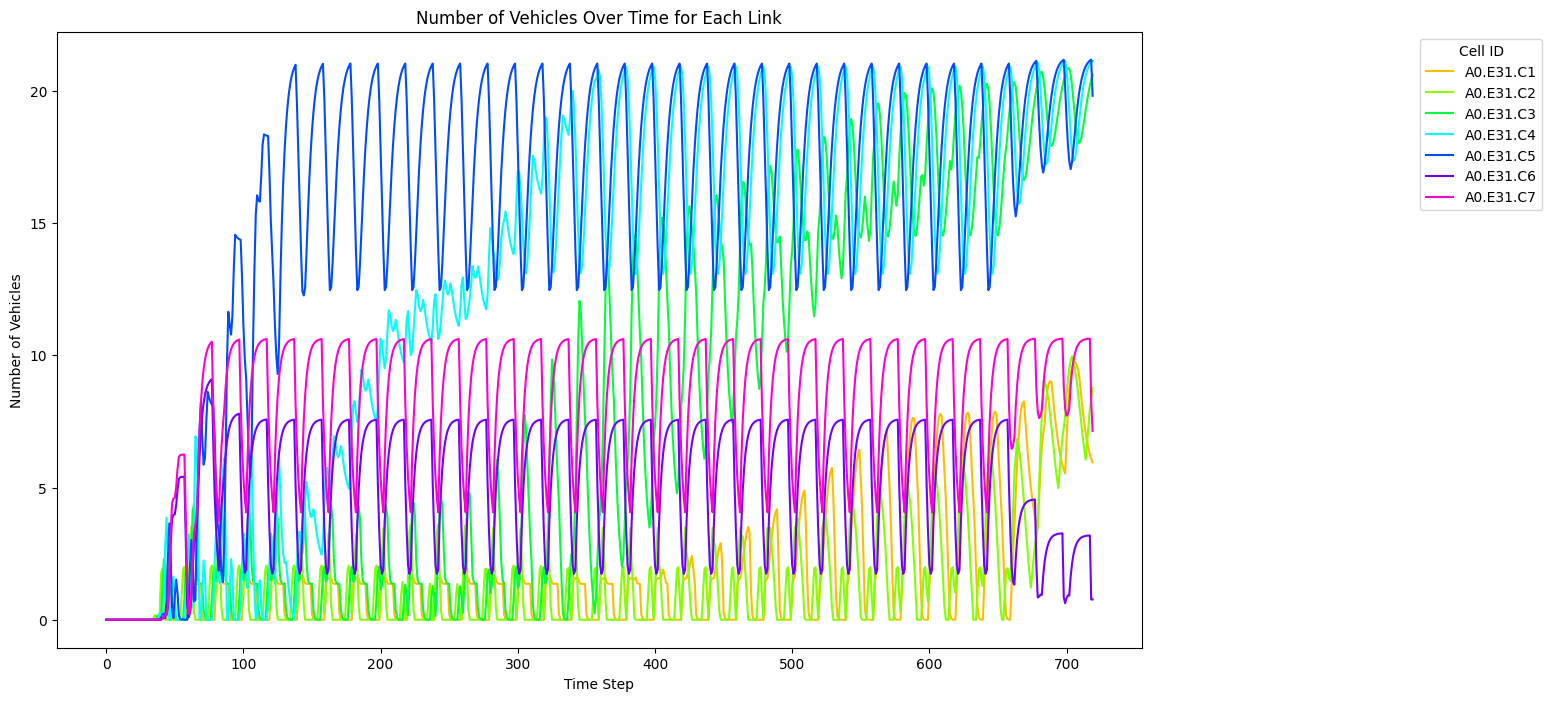

In [609]:
ctm_celldf = pd.read_csv('CTMnumber_600_2400.csv')


ctm_celldf.columns = ['cell_id'] + list(ctm_celldf.columns[1:])

# Define the link IDs to visualize
cell_select = ['A0.E31.C1', 'A0.E31.C2', 'A0.E31.C3', 'A0.E31.C4', 'A0.E31.C5', 'A0.E31.C6', 'A0.E31.C7']

# cell_select = ['A0.E28.C5', 'A0.E28.C6', 'A0.E28.C7',
#                'A0.E18.C1', 'A0.E18.C2', 'A0.E18.C3',
#                'A0.-E17.C1', 'A0.-E17.C2', 'A0.-E17.C3',
#                'A1.-E115.C1', 'A1.-E115.C2', 'A1.-E115.C3',]

# cell_select = ['A1.E101.C4', 'A1.E101.C5','A1.E101.C6', 'A1.E101.C7',]

# cell_select = ['A1.-E115.C1', 'A1.-E115.C2', 'A1.-E115.C3', 'A1.-E115.C4', 'A1.-E115.C0']

plot_cell_vehicle_number(ctm_celldf, 1, cell_select)